In [260]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [261]:

#load dataset
data = pd.read_excel(r"../df.xlsx")
df = data.iloc[27:,:] # from 1992-2025
df.head()


print(df.info())

print(df.shape)

df = df.sort_values('Date')

df.set_index('Date', inplace=True)
df.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 27 to 93
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       67 non-null     datetime64[us]
 1   Year                       67 non-null     int64         
 2   Season                     67 non-null     str           
 3   Sown_Extent_Major          67 non-null     int64         
 4   Sown_Extent_Minor          67 non-null     int64         
 5   Sown_Extent_Rainfall       67 non-null     int64         
 6   Sown_Extent_Total          67 non-null     int64         
 7   Harvested_Extent_Major     67 non-null     int64         
 8   Harvested_Extent_Minor     67 non-null     int64         
 9   Harvested_Extent_Rainfall  67 non-null     int64         
 10  Harvested_Extent_Total     67 non-null     int64         
 11  Avg_Yield_Major            67 non-null     int64         
 12  Avg_Yield_Minor     

,Year,Season,Sown_Extent_Major,Sown_Extent_Minor,Sown_Extent_Rainfall,Sown_Extent_Total,Harvested_Extent_Major,Harvested_Extent_Minor,Harvested_Extent_Rainfall,Harvested_Extent_Total,...,Fung_Used,Fung_NotUsed,Short_Grain_Red,Long_Grain_Red,Short_Grain_White,Long_Grain_White,Other(seed_variety),New_Improved,Old_Improved,Traditional
Date,,,,,,,,,,,,,,,,,,,,,
1992-04-01,1992,Yala,130502,49825,74657,254983,122937,47463,72833,243236,...,24.10,75.90,0.0,0.0,0.0,0.0,0.0,90.55,0.81,8.64
1992-09-01,1993,Maha,247069,130475,168145,545689,245058,127580,165398,538060,...,24.32,75.68,0.0,0.0,0.0,0.0,0.0,89.89,1.43,8.68
1993-04-01,1993,Yala,162398,45118,81088,288605,160944,43231,77531,281706,...,18.27,81.73,0.0,0.0,0.0,0.0,0.0,90.25,1.12,8.63


In [262]:
ts = df["Production"]
ts.tail()

Date
2023-04-01    1817.39
2023-09-01    2721.96
2024-04-01    1976.50
2024-09-01    2745.30
2025-04-01    2308.40
Name: Production, dtype: float64

In [263]:
# train / test split
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 53
Test size: 14


In [264]:
# normalized
scaler = MinMaxScaler(feature_range=(-1, 1))

train_data = train.values.reshape(-1, 1)
train_scaled = scaler.fit_transform(train_data)

train_scaled = torch.FloatTensor(train_scaled).view(-1)

In [265]:
type(train_scaled)

torch.Tensor

In [266]:
# create sequences
def create_inout_sequences(input_data, seq_len):
    inout_seq = []
    L = len(input_data)

    for i in range(L - seq_len):
        train_seq = input_data[i:i+seq_len]
        train_label = input_data[i+seq_len:i+seq_len+1]
        inout_seq.append((train_seq, train_label))

    return inout_seq


seq_len = 5
train_sequences = create_inout_sequences(train_scaled, seq_len)

In [267]:
# lstm model
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, output_size=1):
        super().__init__()

        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(input_size, hidden_size)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq.view(len(input_seq), 1, -1))
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        return predictions[-1]


model = LSTM()

loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [268]:
# training
epochs = 50
losses = []

for epoch in range(epochs):
    epoch_loss = 0

    for seq, label in train_sequences:
        optimizer.zero_grad()

        y_pred = model(seq)
        loss = loss_function(y_pred, label)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss / len(train_sequences))

    print(f"Epoch {epoch+1}/{epochs}, Loss: {losses[-1]:.6f}")

Epoch 1/50, Loss: 0.296239
Epoch 2/50, Loss: 0.274038
Epoch 3/50, Loss: 0.264484
Epoch 4/50, Loss: 0.246942
Epoch 5/50, Loss: 0.194168
Epoch 6/50, Loss: 0.141335
Epoch 7/50, Loss: 0.128619
Epoch 8/50, Loss: 0.114241
Epoch 9/50, Loss: 0.107837
Epoch 10/50, Loss: 0.103403
Epoch 11/50, Loss: 0.100776
Epoch 12/50, Loss: 0.098762
Epoch 13/50, Loss: 0.097008
Epoch 14/50, Loss: 0.095422
Epoch 15/50, Loss: 0.093894
Epoch 16/50, Loss: 0.092400
Epoch 17/50, Loss: 0.090920
Epoch 18/50, Loss: 0.089438
Epoch 19/50, Loss: 0.087942
Epoch 20/50, Loss: 0.086423
Epoch 21/50, Loss: 0.084877
Epoch 22/50, Loss: 0.083301
Epoch 23/50, Loss: 0.081698
Epoch 24/50, Loss: 0.080077
Epoch 25/50, Loss: 0.078450
Epoch 26/50, Loss: 0.076835
Epoch 27/50, Loss: 0.075244
Epoch 28/50, Loss: 0.073677
Epoch 29/50, Loss: 0.072120
Epoch 30/50, Loss: 0.070552
Epoch 31/50, Loss: 0.068956
Epoch 32/50, Loss: 0.067329
Epoch 33/50, Loss: 0.065681
Epoch 34/50, Loss: 0.064031
Epoch 35/50, Loss: 0.062401
Epoch 36/50, Loss: 0.060810
E

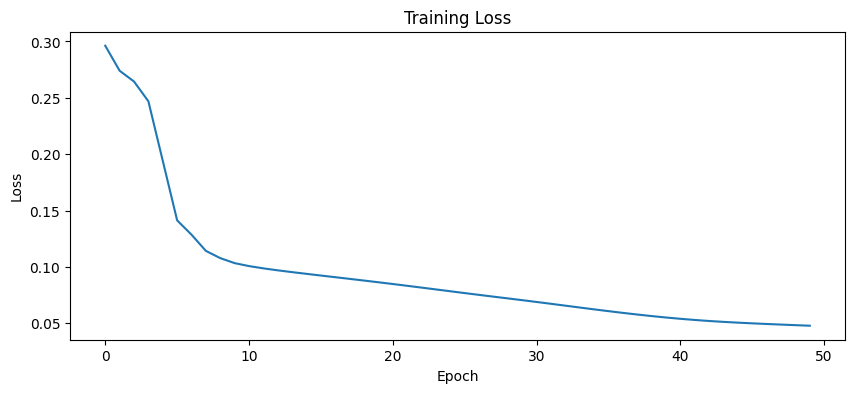

In [269]:
# loss plot
plt.figure(figsize=(10,4))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [270]:
# prediction
model.eval()

predictions = []

test_input = train_scaled[-seq_len:].clone()

with torch.no_grad():
    for i in range(len(test)):
        y_pred = model(test_input)
        predictions.append(y_pred.item())

        test_input = torch.cat((test_input[1:], y_pred.view(1)))

In [271]:
# inverse transform
predictions = np.array(predictions).reshape(-1, 1)
predictions = scaler.inverse_transform(predictions)

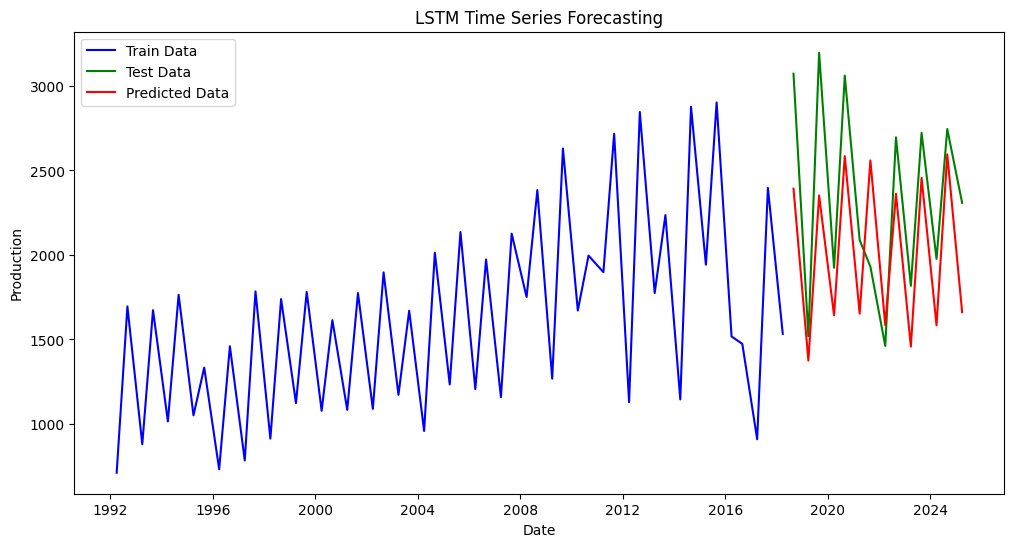

In [272]:
# plot result
train_plot = ts[:train_size]
test_plot = ts[train_size:]

plt.figure(figsize=(12,6))

plt.plot(train_plot.index, train_plot.values, label="Train Data", color="blue")
plt.plot(test_plot.index, test_plot.values, label="Test Data", color="green")
plt.plot(test_plot.index, predictions, label="Predicted Data", color="red")

plt.title("LSTM Time Series Forecasting")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

In [273]:
# evaluation matrix
# from sklearn.metrics import mean_squared_error, mean_absolute_error

# ======================
# ALIGN ARRAYS
# ======================
y_true = test_plot.values
y_pred = predictions.reshape(-1)

# ======================
# METRICS
# ======================
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mse = mean_squared_error(y_true, y_pred)

# MAPE (avoid divide-by-zero)
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

print("\n📊 Model Evaluation Metrics")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"MAPE : {mape:.2f}%")


📊 Model Evaluation Metrics
MAE  : 411.8309
RMSE : 463.7760
MSE  : 215088.1379
MAPE : 17.54%


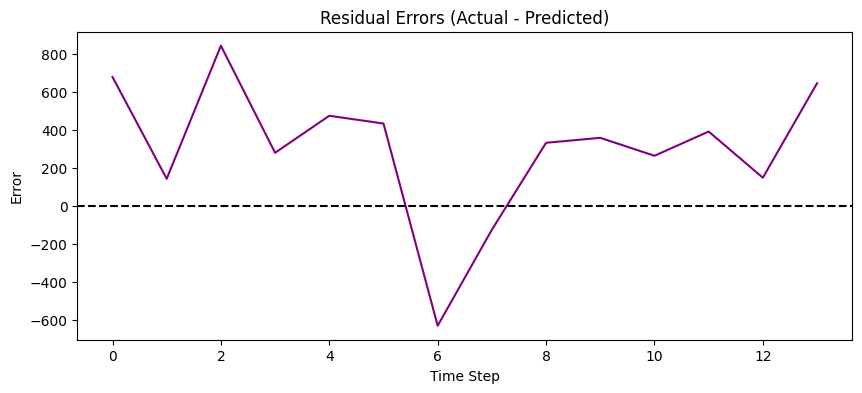

In [274]:
# residual error plot
residuals = y_true - y_pred

plt.figure(figsize=(10,4))
plt.plot(residuals, color="purple")
plt.axhline(0, linestyle="--", color="black")
plt.title("Residual Errors (Actual - Predicted)")
plt.xlabel("Time Step")
plt.ylabel("Error")
plt.show()

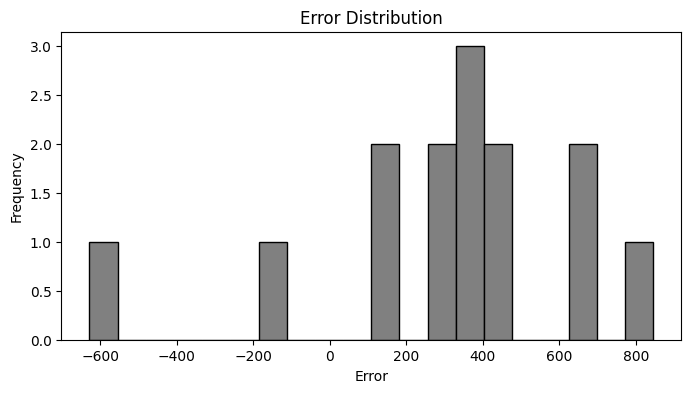

In [275]:
#Error Distribution (Check model quality)
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=20, color="gray", edgecolor="black")
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()